# Parte 1: Análise Exploratória

## Panorama dos Chamados

**Objetivo**: Explorar o corpus de 5.000 chamados da Central 1746 para entender as características e padrões dos dados. A análise foca no **problema de classificação**, de forma a encontrar possíveis insights que possam ajudar durante o processo de modelagem do problema.

## Setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

DADOS_PATH = Path('../dados/chamados_com_predicoes.csv')
FIGURES_PATH = Path('../results/figures')

## Análise Inicial dos Dados

In [2]:
df = pd.read_csv(DADOS_PATH, encoding='utf-8')

In [3]:
df.head()

,id_chamado,data_abertura,bairro,canal,texto,categoria_real,pred_modelo_a,conf_modelo_a,pred_modelo_b,conf_modelo_b
0,2026003525,2026-01-16,Botafogo,app_1746,Festas com som automotivo ocorrem toda madruga...,barulho_perturbacao,barulho_perturbacao,0.939,barulho_perturbacao,0.883
1,2026001235,2026-06-20,Ilha do Governador,telefone_1746,Festas com som automotivo ocorrem toda madruga...,barulho_perturbacao,barulho_perturbacao,0.927,barulho_perturbacao,0.975
2,2026003000,2026-02-17,Campo Grande,portal_web,Solicito reparo urgente na iluminação pública ...,iluminacao_publica,iluminacao_publica,0.947,iluminacao_publica,0.829
3,2026002594,2026-01-15,Tijuca,app_1746,A luminária do poste da Rua Dias da Cruz esqui...,iluminacao_publica,coleta_lixo,0.964,iluminacao_publica,0.882
4,2026003670,2026-01-07,Penha,app_1746,Solicito remoção de entulho e lixo acumulado n...,coleta_lixo,buraco_via,0.924,coleta_lixo,0.765


In [4]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())

(5000, 10)
id_chamado          int64
data_abertura      object
bairro             object
canal              object
texto              object
categoria_real     object
pred_modelo_a      object
conf_modelo_a     float64
pred_modelo_b      object
conf_modelo_b     float64
dtype: object
id_chamado        0
data_abertura     0
bairro            0
canal             0
texto             0
categoria_real    0
pred_modelo_a     0
conf_modelo_a     0
pred_modelo_b     0
conf_modelo_b     0
dtype: int64


In [5]:
ids_duplicados = df['id_chamado'].duplicated().sum()
print(f'IDs duplicados: {ids_duplicados}')

IDs duplicados: 0


In [6]:
resumo_base = {
    'total_chamados': len(df),
    'periodo_inicio': df['data_abertura'].min(),
    'periodo_fim': df['data_abertura'].max(),
    'n_categorias': df['categoria_real'].nunique(),
    'n_bairros': df['bairro'].nunique(),
    'n_canais': df['canal'].nunique()
}

resumo_base

{'total_chamados': 5000,
 'periodo_inicio': '2026-01-01',
 'periodo_fim': '2026-06-30',
 'n_categorias': 8,
 'n_bairros': 15,
 'n_canais': 3}

## Análise Exploratória

In [7]:
cat_map = {
    'iluminacao_publica': 'Iluminação Pública',
    'buraco_via': 'Buraco em Via',
    'coleta_lixo': 'Coleta de Lixo',
    'esgoto_vazamento': 'Vazamento de Esgoto',
    'poda_arvore': 'Poda de Árvore',
    'estacionamento_irregular': 'Estacionamento Irregular',
    'barulho_perturbacao': 'Barulho / Perturbação',
    'sinalizacao': 'Sinalização'
}

cat_palette = {
    'iluminacao_publica': '#f4a261',
    'buraco_via': '#e76f51',
    'coleta_lixo': '#2a9d8f',
    'esgoto_vazamento': '#264653',
    'poda_arvore': '#8ab17d',
    'estacionamento_irregular': '#6b4c3b',
    'barulho_perturbacao': '#e9c46a',
    'sinalizacao': '#7b9ebf'
}

### 1. Distribuição das Categorias

In [8]:
cat_counts = df['categoria_real'].value_counts()
cat_props = df['categoria_real'].value_counts(normalize=True)

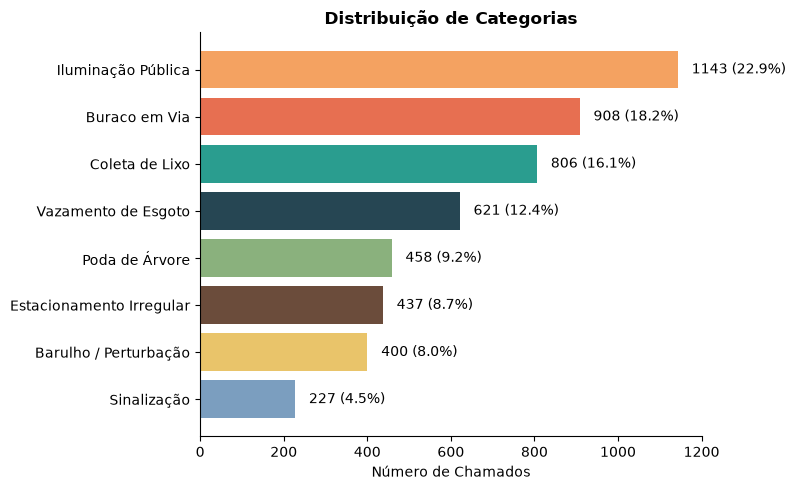

In [9]:
total = cat_counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    [cat_map.get(c, c) for c in cat_counts.index],
    cat_counts.values,
    color=[cat_palette.get(c, '#888') for c in cat_counts.index]
)

labels = [
    f'{v} ({v/total:.1%})'
    for v in cat_counts.values
]

ax.bar_label(bars, labels=labels, padding=10)

ax.set_xlabel('Número de Chamados')
ax.set_title('Distribuição de Categorias', fontweight='bold')
ax.invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'categoria_distribuicao.png', dpi=150)
plt.show()

### 2. Características dos Textos

In [10]:
df['texto_len'] = df['texto'].str.len()
df['texto_words'] = df['texto'].str.split().str.len()

print('Estatísticas gerais do texto:')
print(f'Comprimento (caracteres): média={df["texto_len"].mean():.1f}, mediana={df["texto_len"].median():.0f}, std={df["texto_len"].std():.1f}')
print(f'Palavras: média={df["texto_words"].mean():.1f}, mediana={df["texto_words"].median():.0f}, std={df["texto_words"].std():.1f}\n')

stats_text = df.groupby('categoria_real')['texto_len'].agg(['mean', 'median', 'std', 'min', 'max'])
stats_text.index = [cat_map.get(c, c) for c in stats_text.index]
stats_text.columns = ['Média', 'Mediana', 'Desvio Padrão', 'Mín', 'Máx']
print('Estatísticas por categoria:')
print(stats_text.round(1).to_string())

Estatísticas gerais do texto:
Comprimento (caracteres): média=128.2, mediana=156, std=57.1
Palavras: média=23.3, mediana=28, std=10.6

Estatísticas por categoria:
                          Média  Mediana  Desvio Padrão  Mín  Máx
Barulho / Perturbação     120.8    147.0           54.5   30  191
Buraco em Via             127.5    154.0           58.9   24  197
Coleta de Lixo            125.4    156.0           54.6   27  178
Vazamento de Esgoto       134.6    161.0           56.1   29  199
Estacionamento Irregular  127.0    150.0           53.7   29  192
Iluminação Pública        130.0    160.0           59.6   28  193
Poda de Árvore            131.4    160.0           59.2   27  199
Sinalização               124.3    153.0           54.0   31  180


#### 2.1 Termos distintos por categoria

In [11]:
stopwords_pt = [
    'a', 'o', 'as', 'os', 'um', 'uma', 'uns', 'umas',
    'de', 'do', 'da', 'dos', 'das',
    'em', 'no', 'na', 'nos', 'nas',
    'para', 'por', 'com', 'sem',
    'que', 'e', 'ou', 'ao', 'à',
    'rua', 'avenida', 'av', 'local', 'já',
    'não'
]

In [12]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=stopwords_pt,
    ngram_range=(1, 1),
    min_df=5,
    max_df=0.3
)

X = vectorizer.fit_transform(df['texto'])
terms = np.array(vectorizer.get_feature_names_out())

In [26]:
categorias = sorted(df['categoria_real'].unique())

resultados = []

for categoria in categorias:
    idx_categoria = (df['categoria_real'] == categoria).to_numpy()
    idx_fora = ~idx_categoria
    
    tfidf_mean_categoria = X[idx_categoria].mean(axis=0).A1
    tfidf_mean_fora = X[idx_fora].mean(axis=0).A1
    
    diferenca = tfidf_mean_categoria - tfidf_mean_fora
    
    top_idx = diferenca.argsort()[::-1][:10]
    
    for i in top_idx:
        resultados.append({
            'categoria': categoria,
            'termo': terms[i],
            'tfidf_mean_categoria': tfidf_mean_categoria[i],
            'tfidf_mean_fora': tfidf_mean_fora[i],
            'diferenca': diferenca[i],
        })

termos_distintivos = pd.DataFrame(resultados)

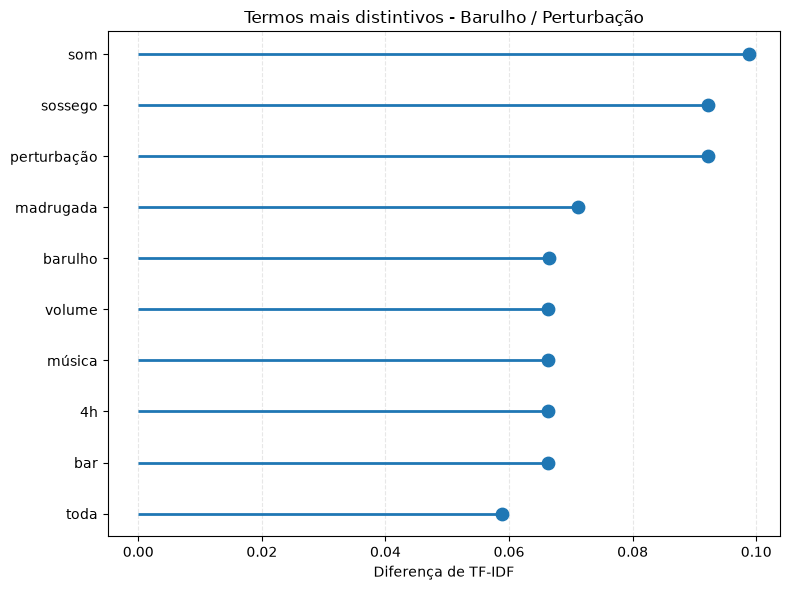

In [31]:
categoria = "barulho_perturbacao"

dados = (
    termos_distintivos
    .query("categoria == @categoria")
    .sort_values("diferenca")
)

fig, ax = plt.subplots(figsize=(8,6))

ax.hlines(
    y=dados["termo"],
    xmin=0,
    xmax=dados["diferenca"],
    linewidth=2
)

ax.scatter(
    dados["diferenca"],
    dados["termo"],
    s=80,
    zorder=3
)

ax.set_xlabel("Diferença de TF-IDF")
ax.set_ylabel("")
ax.set_title(f"Termos mais distintivos - {cat_map.get(categoria, categoria)}")

ax.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
top_termos_por_categoria = (
    termos_distintivos
    .groupby('categoria')['termo']
    .apply(lambda x: ', '.join(x))
    .reset_index()
)

top_termos_por_categoria

,categoria,termo
0,barulho_perturbacao,"som, perturbação, sossego, madrugada, barulho,..."
1,buraco_via,"buraco, cedeu, asfalto, cratera, pista, ônibus..."
2,coleta_lixo,"lixo, coleta, acumulado, entulho, passa, caçam..."
3,esgoto_vazamento,"água, esgoto, vazamento, bueiro, transbordando..."
4,estacionamento_irregular,"vaga, deficiente, fila, dupla, veículo, abando..."
5,iluminacao_publica,"poste, lâmpada, fica, luz, queimada, iluminaçã..."
6,poda_arvore,"poda, árvore, galhos, avaliação, precisa, sobr..."
7,sinalizacao,"sinalização, placa, semáforo, cruzamento, atra..."
